In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.nn import MSELoss
import os, sys
# os.chdir("..")
sys.path.append(os.path.join(os.getcwd().split("KAMemory")[0], "KAMemory/src"))

from pprint import pprint
import models
import utils
#import main
import training
import evolution_dir._utils_ev as ev

from logger import logger

from tqdm import tqdm
from scipy.ndimage import convolve1d

%load_ext autoreload
%autoreload

logger(".")

2026-04-20 13:46:25 | .


In [2]:
class Settings:
    num = 1000
    load = True
    idx = 0
    use_bias = True
    
args = Settings()

if args.load:
    info, autoencoder = models.load_session(idx=args.idx)
    dim_ei = info["dim_ei"]
    dim_ca3 = info["dim_ca3"]
    dim_ca1 = info["dim_ca1"]
    dim_eo = info["dim_eo"]

    print(info)
    num_samples = info["num_samples"]

    K_lat = info["K_lat"]
    beta = info["beta"]
    K = info["K"]

    # get parameters
    W_ei_ca1, W_ca1_eo, B_ei_ca1, B_ca1_eo = autoencoder.get_weights(bias=True)

    logger(f"{autoencoder=}")

    logger("<<< Loaded session >>>")
else:
    dim_ei = 50
    dim_ca3 = 50 
    dim_ca1 = 50
    dim_eo = dim_ei

    # data settings
    num_samples = 2000

    # model hyper-parameters
    K = 5
    K_lat = 15
    beta = 60

    # autoencoder
    autoencoder = models.Autoencoder(input_dim=dim_ei,
                                      encoding_dim=dim_ca1,
                                      activation=None,
                                      K=K_lat,
                                      beta=beta,
                                      use_bias=args.use_bias)
    logger(f"%Autoencoder: {autoencoder}")

2026-04-20 13:46:25 | Pre-selected session: [0]
2026-04-20 13:46:25 | bias not found in the info file, set to True
2026-04-20 13:46:25 | Retrieved autoencoder hyper-parameters and session:
2026-04-20 13:46:25 | autoencoder=Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=50, out_features=50, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=50, out_features=50, bias=True)
  )
)
2026-04-20 13:46:25 | <<< Loaded session >>>


{'K': 5,
 'K_lat': 15,
 'beta': 60,
 'dim_ca1': 50,
 'dim_ca3': 50,
 'dim_ei': 50,
 'dim_eo': 50,
 'epochs': 500,
 'loss_ae': 0.05726,
 'num_reconstructions': 1,
 'num_samples': 10000}
{'dim_ei': 50, 'dim_ca3': 50, 'dim_ca1': 50, 'dim_eo': 50, 'num_samples': 10000, 'num_reconstructions': 1, 'K': 5, 'K_lat': 15, 'beta': 60, 'epochs': 500, 'loss_ae': 0.05726}


In [4]:
""" retrieve autoencoder parameters """

# get weights from the autoencoder
if args.use_bias:
    W_ei_ca1, W_ca1_eo, B_ei_ca1, B_ca1_eo = autoencoder.get_weights(bias=True)
else:
    W_ei_ca1, W_ca1_eo = autoencoder.get_weights(bias=False)
    B_ei_ca1 = None
    B_ca1_eo = None
logger()

2026-04-20 13:41:33 | 


# evolution

---

In [3]:
""" data """

num_samples = 200

stimuli = utils.sparse_stimulus_generator(N=num_samples,
                                          K=K,
                                          size=dim_ei,
                                          plot=False)

datasets = []
for k in range(num_samples):
    data = torch.tensor(stimuli[:k+1], dtype=torch.float32)
    dataloader = DataLoader(TensorDataset(data),
                            batch_size=1,
                            shuffle=False)
    datasets += [dataloader]

logger()

2026-04-17 17:44:19 | 


In [13]:
""" load model paramters """

session = ev.load_genome(index=-2)
genome = session["genome"]

print(session)

available:
0:run_9_93_2153.json
1:run_12_173_1530.json
2:run_1_63_029.json
3:run_20_44_1558.json
4:run_8_93_106.json
5:run_6_83_1451.json
6:run_10_103_1129.json
7:run_15_233_1633.json
8:run_13_183_1215.json
9:run_22_34_456.json
10:run_11_163_213.json
11:run_23_34_1734.json
12:run_18_34_335.json
13:run_16_253_123.json
14:run_0_63_016.json
15:run_5_73_2042.json
16:run_2_63_053.json
17:run_4_63_100.json
18:run_17_313_1950.json
19:run_19_44_1245.json
20:run_3_63_10.json
21:run_21_34_421.json
22:run_7_83_1941.json
23:run_14_193_758.json


index:  


ValueError: invalid literal for int() with base 10: ''

In [4]:
for i in range(23):
    session = ev.load_genome(index=i+1)
    print(session)
    print()

load name='/home/doki/main_lab/KAMemory/src/evolution_dir/logs/run_12_173_1530.json'
{'genome': {'K_lat': 1.1104656457901, 'K_ca3': 1.055088996887207, 'K_out': 0.6342002749443054, 'beta': 0.06890071928501129, 'alpha': 0.35160940885543823}, 'fitness': 0.47758297877022393, 'dim_ei': 100, 'dim_ca1': 1000, 'dim_eo': 100, 'K': 10}

load name='/home/doki/main_lab/KAMemory/src/evolution_dir/logs/run_1_63_029.json'
{'genome': [-5.229095458984375, -199.53575134277344, -253.64813232421875, -3.7578744888305664, -179.34481811523438], 'fitness': 0.3171803434379398, 'dim_ei': 50, 'dim_ca1': 50, 'dim_eo': 50, 'K': 5}

load name='/home/doki/main_lab/KAMemory/src/evolution_dir/logs/run_20_44_1558.json'
{'genome': {'K_ca3': -36.05577850341797, 'beta_eo': 0.8311077952384949, 'beta_is': 11.491485595703125, 'beta_ca1': 45.22932815551758, 'beta_ca3': 15.368042945861816, 'alpha': 60.65691375732422}, 'fitness': 0.6397697005235575, 'dim_ei': 50, 'dim_ca1': 50, 'dim_eo': 50, 'dim_ca3': 50, 'K': 18}

load name='

In [19]:
""" settings """

def run_model(num_reps: int, num_samples: int, parameters: dict,
              settings: dict):

    K_lat = parameters['K_lat']
    K_ca3 = parameters['K_ca3']
    K_out = parameters['K_out']
    beta = parameters['beta']
    alpha = parameters['alpha']
    
    K = settings["K"]
    dim_ei = settings["dim_ei"]
    W_ei_ca1 = settings["W_ei_ca1"]
    W_ca1_eo = settings["W_ca1_eo"]
    B_ei_ca1 = settings["B_ei_ca1"]
    B_ca1_eo = settings["B_ca1_eo"]
    num_swaps_ca1 = parameters["num_swaps_ca1"]
    num_swaps_ca3 = parameters["num_swaps_ca3"]
    
    accuracy = np.zeros((num_reps, num_samples, num_samples))
    sim_ca1_is = np.zeros((num_reps, num_samples, num_samples))
    distances = np.zeros((num_reps, num_samples, num_samples))
    
    """ run """
    for l in tqdm(range(num_reps), disable=False):
    
        # data
        stimuli = utils.sparse_stimulus_generator(N=num_samples,
                                                  K=K,
                                                  size=dim_ei,
                                                  plot=False)
    
        datasets = []
        for k in range(num_samples):
            data = torch.tensor(stimuli[:k+1], dtype=torch.float32)
            dataloader = DataLoader(TensorDataset(data),
                                    batch_size=1,
                                    shuffle=False)
            datasets += [dataloader]
        
        # run
        for i in tqdm(range(num_samples), disable=True):
        
            # make model
            """model = models.MTL(W_ei_ca1=W_ei_ca1,
                               W_ca1_eo=W_ca1_eo,
                               B_ei_ca1=B_ei_ca1,
                               B_ca1_eo=B_ca1_eo,
                               dim_ca3=dim_ei,
                               K_lat=K_lat,
                               K_ca3=K_ca3,
                               K_out=K_out,
                               beta=beta,
                               alpha=alpha)"""

            model = models.MTLev(W_ei_ca1=W_ei_ca1,
                   W_ca1_eo=W_ca1_eo,
                   K_lat=K_lat,
                   K_out=K_out,
                   K_ca3=K_ca3,
                   dim_ca3=dim_ei,
                   beta_eo=beta_eo,
                   beta_is=beta_is,
                   beta_ca1=beta_ca1,
                   beta_ca3=beta_ca3,
                   alpha=alpha,
                   num_swaps_ca1=num_swaps_ca1,
                   num_swaps_ca3=num_swaps_ca3,
                   B_ei_ca1=B_ei_ca1,
                   B_ca1_eo=B_ca1_eo)

        
            
            # train a dataset with pattern index 0.. i
            model.eval()
            with torch.no_grad():
        
                # one pattern at a time
                for j, batch in enumerate(datasets[i]):
                    # forward
                    _ = model(batch[0].reshape(-1, 1))
        
                    # to delete?
                    sim_ca1_is[l, i, j] = utils.cosine_similarity_vec(
                        model.recordings['ca1'][-1],
                        model.recordings['IS'][-1])
                    distances[l, i, j] = i-j
        
            # test a dataset with pattern index 0.. i 
            model.pause_lr()
            model.eval()
            with torch.no_grad():
                # one pattern at a time
                for j, batch in enumerate(datasets[i]):
                    x = batch[0].reshape(-1, 1)
        
                    # forward
                    y = model(x)
                    # logger.debug(f"{x.shape}, {y.shape}")
        
                    # record : cosine similarity
                    # outputs[l, h, i, j] = (y.T @ x) / \
                    #     (torch.norm(x) * torch.norm(y))
        
                    value = (y.T @ x) / (torch.norm(x) * torch.norm(y))
        
                    accuracy[l, i, j] = (value.item() - 0.2) / 0.8
                    
                    sim_ca1_is[l, i, j] = utils.cosine_similarity_vec(
                        model.recordings['ca1'][-1],
                        model.recordings['IS'][-1])
                    distances[l, i, j] = i-j

    return accuracy

logger()

2026-04-17 17:52:09 | 


### comparison with a custom model parametrization

In [20]:
num_reps = 5
num_samples = 100
run_settings = {"K": K,
                "dim_ei": dim_ei,
                "W_ei_ca1": W_ei_ca1,
                "W_ca1_eo": W_ca1_eo,
                "B_ei_ca1": B_ei_ca1,
                "B_ca1_eo": B_ca1_eo}

# -- evolved
logger("%evolved")
parameters = ev.load_genome(index=-2)["genome"]
parameters["K_lat"] = int(max((1, 10*parameters["K_lat"])))
parameters["K_ca3"] = int(max((1, 10*parameters["K_ca3"])))
parameters["K_out"] = int(max((1, 10*parameters["K_out"])))
parameters["beta"] = abs(100*parameters["beta"])
parameters["alpha"] = np.clip(parameters["alpha"], 0.01, 0.99).item() if 1 else 0.2

outputs_ev = run_model(num_reps=num_reps, num_samples=num_samples, parameters=parameters,
                    settings=run_settings)

# -- custom
logger("%custom")
parameters_cu = {"K_lat": 15, "K_ca3": 15, "K_out": K, "beta": 60., "alpha": 0.1}

outputs_cu = run_model(num_reps=num_reps, num_samples=num_samples, parameters=parameters_cu,
                       settings=run_settings)
logger()

2026-04-17 17:52:12 | %evolved


available:
0:run_9_93_2153.json
1:run_12_173_1530.json
2:run_1_63_029.json
3:run_20_44_1558.json
4:run_8_93_106.json
5:run_6_83_1451.json
6:run_10_103_1129.json
7:run_15_233_1633.json
8:run_13_183_1215.json
9:run_22_34_456.json
10:run_11_163_213.json
11:run_23_34_1734.json
12:run_18_34_335.json
13:run_16_253_123.json
14:run_0_63_016.json
15:run_5_73_2042.json
16:run_2_63_053.json
17:run_4_63_100.json
18:run_17_313_1950.json
19:run_19_44_1245.json
20:run_3_63_10.json
21:run_21_34_421.json
22:run_7_83_1941.json
23:run_14_193_758.json


index:  23


load name='/home/doki/main_lab/KAMemory/src/evolution_dir/logs/run_14_193_758.json'


KeyError: 'num_swaps_ca1'

custom parameters:
{'K_ca3': 15, 'K_lat': 15, 'K_out': 5, 'alpha': 0.1, 'beta': 60.0}

evolved parameters:
{'K_ca3': 1, 'K_lat': 17, 'K_out': 5, 'alpha': 0.01, 'beta': 4.880191758275032}


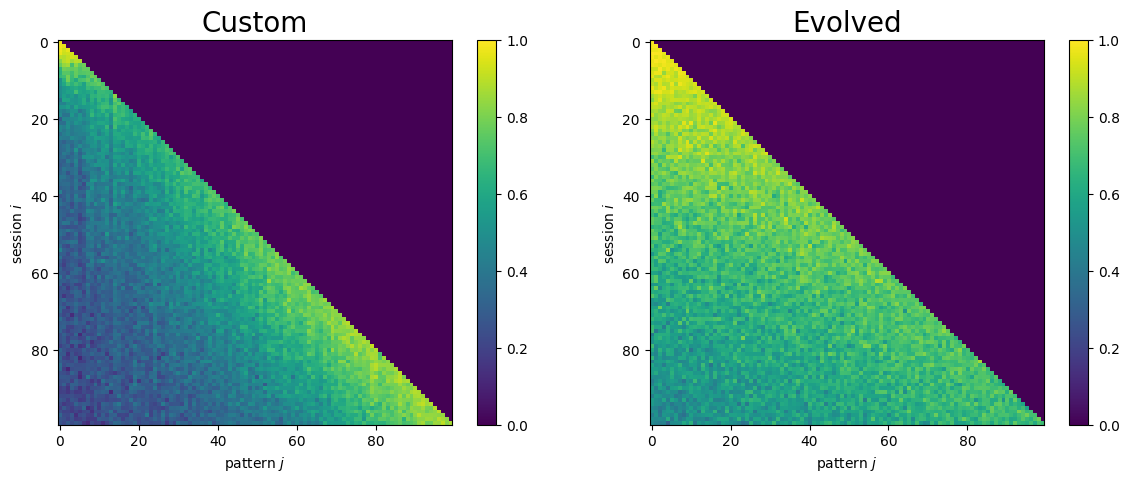

In [10]:
""" plot """

outputs1_ev = outputs_ev.mean(axis=0)
outputs1_cu = outputs_cu.mean(axis=0)

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(14, 5))

cax1 = ax1.imshow(outputs1_ev, cmap="viridis",
           vmin=0, vmax=1, aspect="auto")
ax1.set_title(f"Evolved", fontsize=20)
ax1.set_xlabel("pattern $j$")
ax1.set_ylabel("session $i$")

cax2 = ax2.imshow(outputs1_cu, cmap="viridis",
           vmin=0, vmax=1, aspect="auto")
ax2.set_title(f"Custom", fontsize=20)
ax2.set_xlabel("pattern $j$")
ax2.set_ylabel("session $i$")

print("custom parameters:")
pprint(parameters_cu)
print()
print("evolved parameters:")
pprint(parameters)

plt.colorbar(cax1)
plt.colorbar(cax2)

plt.show()

In [11]:
""" plot """

outputs1 = outputs.mean(axis=0)

fig0 = plt.figure(figsize=(5, 5))

plt.imshow(outputs1, cmap="viridis",
           vmin=0, vmax=1, aspect="auto")
plt.title(f"Recall quality for all patterns in each session")
plt.xlabel("pattern $j$")
plt.ylabel("session $i$")

plt.show()

NameError: name 'outputs' is not defined

In [248]:
loaded = ev.load_genome(index=7)
print(loaded.keys())

dict_keys(['genome', 'fitness', 'dim_ei', 'dim_ca1', 'dim_eo', 'K'])


In [249]:
loaded['fitness']

0.8542838526017267

In [ ]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# plot
ax.clear()
ax.grid()
for h in range(num_lineages):
    for x, g in enumerate(np.array(record[h]["fitness"])):
        ax.scatter([x]*len(population), g, s=30, color=record[h]["color"],
                   marker="x", alpha=0.1)
    ax.plot(range(len(record[h]["history"])), record[h]["history"], color=record[h]["color"], lw=2)
ax.set_xlabel("generations")
ax.set_ylabel("fitness")

for k in range(dim):
    for h in range(num_lineages):
        ax2[k][h].clear()
        ax2[k][h].grid()
        for x, g in enumerate(np.array(record[h][k])):
            ax2[k][h].scatter([x]*len(g), g, s=30, c=record[h]['fitness'][x],
                           cmap="Blues_r", alpha=0.8)
        ax2[k][h].set_ylabel(f"gene {k}")
        if k == 0:
            ax2[k][h].set_title(f"lineage {h}")

    # ax2[k][h].set_xlabel("generations")

plt.pause(0.001)


# experiment 1

---
**goal** : visualizing the effect of varying $\alpha$ in performance

In [7]:
""" data """

num_samples = 100

stimuli = utils.sparse_stimulus_generator(N=num_samples,
                                          K=K,
                                          size=dim_ei,
                                          plot=False)

datasets = []
for k in range(num_samples):
    data = torch.tensor(stimuli[:k+1], dtype=torch.float32)
    dataloader = DataLoader(TensorDataset(data),
                            batch_size=1,
                            shuffle=False)
    datasets += [dataloader]

logger()

2026-03-31 16:10:47 | 


In [8]:
os.listdir("../src/evolution_dir/logs")

['run_9_93_2153.json',
 'run_12_173_1530.json',
 'run_1_63_029.json',
 'run_8_93_106.json',
 'run_6_83_1451.json',
 'run_10_103_1129.json',
 'run_13_183_1215.json',
 'run_11_163_213.json',
 'run_0_63_016.json',
 'run_5_73_2042.json',
 'run_2_63_053.json',
 'run_4_63_100.json',
 'run_3_63_10.json',
 'run_7_83_1941.json',
 'run_14_193_758.json']

In [13]:
""" load model paramters """

session = ev.load_genome(index=-2)
parameters = session["genome"]
print(session)

available:
0:run_9_93_2153.json
1:run_12_173_1530.json
2:run_1_63_029.json
3:run_8_93_106.json
4:run_6_83_1451.json
5:run_10_103_1129.json
6:run_13_183_1215.json
7:run_11_163_213.json
8:run_0_63_016.json
9:run_5_73_2042.json
10:run_2_63_053.json
11:run_4_63_100.json
12:run_3_63_10.json
13:run_7_83_1941.json
14:run_14_193_758.json


index:  14


{'genome': {'K_lat': 2.4172589778900146, 'K_ca3': 0.38400042057037354, 'K_out': 0.6170844435691833, 'beta': 0.05665505677461624, 'alpha': -0.6736127138137817}, 'fitness': 0.6084463791074032, 'dim_ei': 100, 'dim_ca1': 1000, 'dim_eo': 100, 'K': 10}


In [14]:
# run settings
grid_size = 8
grid = np.linspace(1e-3, 0.9, grid_size)
num_reps = 2
num_samples = 100
run_settings = {"K": K,
                "dim_ei": dim_ei,
                "W_ei_ca1": W_ei_ca1,
                "W_ca1_eo": W_ca1_eo,
                "B_ei_ca1": B_ei_ca1,
                "B_ca1_eo": B_ca1_eo}

# reference model parametrization evolved
#parameters = ev.load_genome(index=7)["genome"]
parameters["K_lat"] = int(max((1, 10*parameters["K_lat"])))
parameters["K_ca3"] = int(max((1, 10*parameters["K_ca3"])))
parameters["K_out"] = int(max((1, 10*parameters["K_out"])))
parameters["beta"] = abs(100*parameters["beta"])

results = []

for v in grid:
    parameters["alpha"] = v

    results += [run_model(num_reps=num_reps,
                           num_samples=num_samples,
                           parameters=parameters,
                           settings=run_settings)]

logger()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:09<00:00,  4.84s/it]
2026-03-31 16:16:25 | 


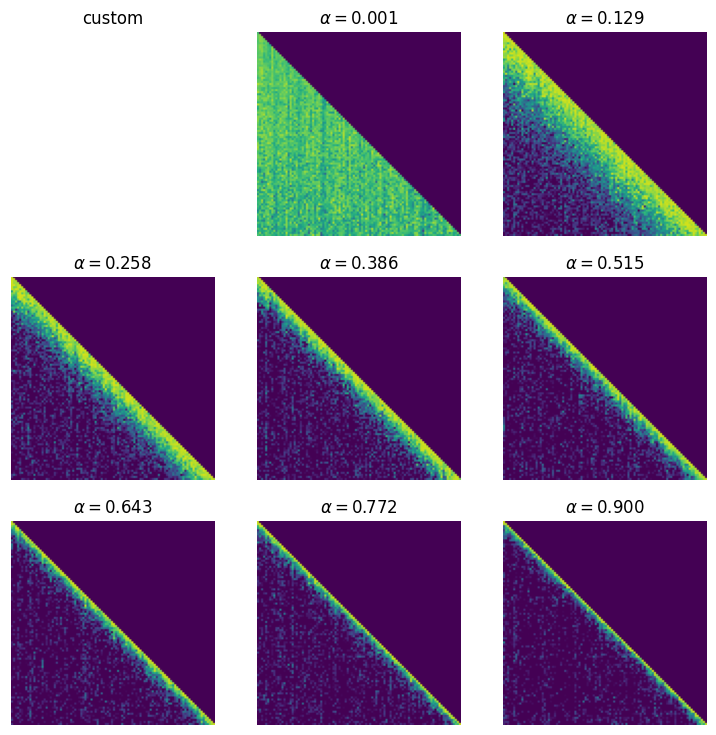

In [15]:
""" plot """
gsqrt = int(np.ceil(np.sqrt(grid_size+1)))
fig, axs = plt.subplots(gsqrt, gsqrt, figsize=((gsqrt)*3, gsqrt*3))
axs = axs.flatten()
#axs[0].imshow(outputs_cu.mean(axis=0), vmin=0., vmax=1.)
axs[0].set_title("custom")
axs[0].axis("off")

for i in range(1, grid_size+1):
    axs[i].imshow(results[i-1].mean(axis=0), vmin=0., vmax=1.)
    axs[i].set_title(f"$\\alpha=${grid[i-1]:.3f}")
    axs[i].axis('off')

plt.show()

---

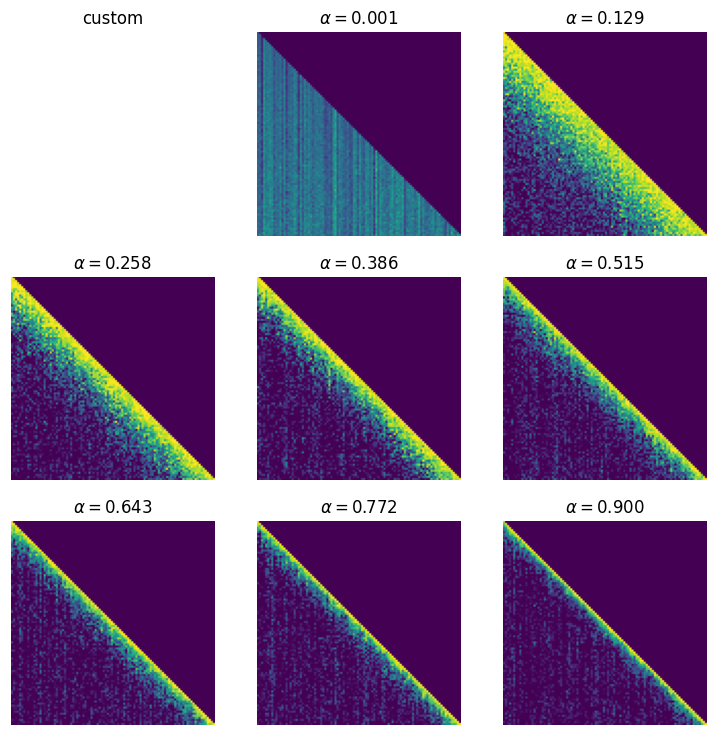

In [10]:
""" plot """
gsqrt = int(np.ceil(np.sqrt(grid_size+1)))
fig, axs = plt.subplots(gsqrt, gsqrt, figsize=((gsqrt)*3, gsqrt*3))
axs = axs.flatten()
#axs[0].imshow(outputs_cu.mean(axis=0), vmin=0., vmax=1.)
axs[0].set_title("custom")
axs[0].axis("off")

for i in range(1, grid_size+1):
    axs[i].imshow(results[i-1].mean(axis=0), vmin=0., vmax=1.)
    axs[i].set_title(f"$\\alpha=${grid[i-1]:.3f}")
    axs[i].axis('off')

plt.show()

In [250]:
print("custom parameters:")
pprint(parameters_cu)
print()
print("evolved parameters:")
pprint(parameters)

custom parameters:
{'K_ca3': 15, 'K_lat': 15, 'K_out': 5, 'alpha': 0.1, 'beta': 60.0}

evolved parameters:
{'K_ca3': 1, 'K_lat': 17, 'K_out': 5, 'alpha': 0.01, 'beta': 4.880191758275032}


In [112]:
""" model parameters """

K_lat = genome['K_lat']
K_ca3 = genome['K_ca3']
K_out = genome['K_out']
beta = genome['beta']
alpha = genome['alpha']


""" settings """
num_reps = 3
num_params = 4

params = np.around(np.linspace(0.01, 1., num_params), num_params)

outputs = np.zeros((num_reps, num_params, num_samples, num_samples))
accuracy = np.zeros((num_reps, num_params, num_samples, num_samples))
sim_ca1_is = np.zeros((num_reps, num_params, num_samples, num_samples))
distances = np.zeros((num_reps, num_params, num_samples, num_samples))

""" run """

for l in tqdm(range(num_reps), disable=True):
    for h, p in enumerate(params):

        # data
        stimuli = utils.sparse_stimulus_generator(N=num_samples,
                                                  K=K,
                                                  size=dim_ei,
                                                  plot=False)

        datasets = []
        for k in range(num_samples):
            data = torch.tensor(stimuli[:k+1], dtype=torch.float32)
            dataloader = DataLoader(TensorDataset(data),
                                    batch_size=1,
                                    shuffle=False)
            datasets += [dataloader]

        # run
        for i in tqdm(range(num_samples), disable=False):

            # make model
            model = models.MTL(W_ei_ca1=W_ei_ca1,
                           W_ca1_eo=W_ca1_eo,
                           B_ei_ca1=B_ei_ca1,
                           B_ca1_eo=B_ca1_eo,
                           dim_ca3=dim_ei,
                           K_lat=int(max((1, 10*K_lat))),
                           K_ca3=int(max((1, 10*K_ca3))),
                           K_out=int(max((1, 10*K_out))),
                           beta=abs(100*beta),
                           #alpha=np.clip(alpha, 0.01, 0.99))
                           alpha=p)

            # train a dataset with pattern index 0.. i
            model.eval()
            with torch.no_grad():

                # one pattern at a time
                for j, batch in enumerate(datasets[i]):
                    # forward
                    _ = model(batch[0].reshape(-1, 1))

                    # to delete?
                    sim_ca1_is[l, h, i, j] = utils.cosine_similarity_vec(
                        model.recordings['ca1'][-1],
                        model.recordings['IS'][-1])
                    distances[l, h, i, j] = i-j

            # test a dataset with pattern index 0.. i 
            model.pause_lr()
            model.eval()
            with torch.no_grad():
                # one pattern at a time
                for j, batch in enumerate(datasets[i]):
                    x = batch[0].reshape(-1, 1)

                    # forward
                    y = model(x)

                    # record : cosine similarity
                    value = (y.T @ x) / (torch.norm(x) * torch.norm(y))

                    outputs[l, h, i, j] = (value.item() - 0.2) / 0.8
                    accuracy[l, h, i, j] = (value.item() - 0.2) / 0.8
                    
                    sim_ca1_is[l, h, i, j] = utils.cosine_similarity_vec(
                        model.recordings['ca1'][-1],
                        model.recordings['IS'][-1])
                    distances[l, h, i, j] = i-j
                    

logger()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 16.84it/s]
2026-03-09 19:10:13 | 


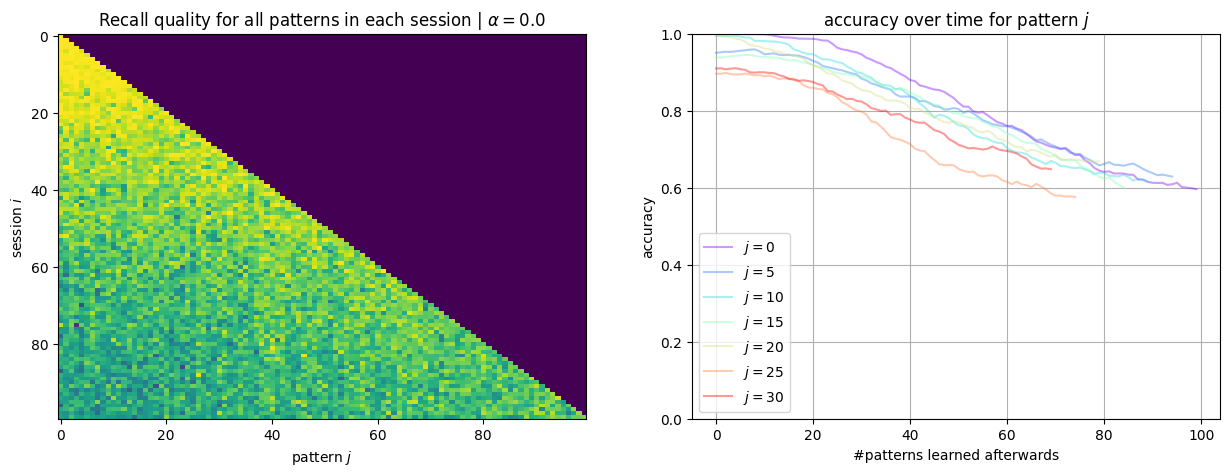

In [120]:
i = 0
outputs1 = outputs.mean(axis=0)[i]
# -> (sample, sample)

fig0 = plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.imshow(outputs1, cmap="viridis",
           vmin=0, vmax=1, aspect="auto")
plt.title(f"Recall quality for all patterns in each session | $\\alpha=${alphas[i]}")
plt.xlabel("pattern $j$")
plt.ylabel("session $i$")


plt.subplot(122)
# plt.axhline(0.1, color="r", linestyle="--",
#             alpha=0.2)
# smoothing
num_p = 7
jumps = 5
colors = plt.cm.rainbow(np.linspace(0, 1, num_p))
for di, d in enumerate(range(0, jumps*num_p, jumps)):
    output_d = outputs1[d:, d] # selection of one pattern
    nsmooth = 30
    padded_d = np.pad(output_d, (nsmooth-1, 0), mode="edge")
    output_d = np.convolve(padded_d,
                          np.ones(nsmooth)/nsmooth,
                          mode="valid")
    plt.plot(output_d, '-', label=f"$j=${d}", alpha=0.4,
             color=colors[di])

plt.ylim(0., 1)
plt.ylabel("accuracy")
plt.xlabel("#patterns learned afterwards")
plt.legend()
plt.title("accuracy over time for pattern $j$")
plt.grid()

plt.show()

In [91]:
genome

[1.5102382898330688,
 -8.961825370788574,
 0.5208773612976074,
 0.04602891579270363,
 -8.08127498626709]

---

In [73]:
""" plot """

# exponential weight
def exp_eval(data: np.ndarray, sigma: float):
    n = len(data)
    out = np.zeros(n)
    for r in range(n):
        denom = 0.
        for c in range(r, -1, -1):
            w = np.exp(-((c-r)/sigma)**2)
            out[r] += w * np.clip(data[r, c], 0., 1.)
            denom += w

        out[r] = out[r] / denom

    return out


results = np.zeros(num_params)
#for i in range(num_params):
#    results[i] = exp(-(i+1)/

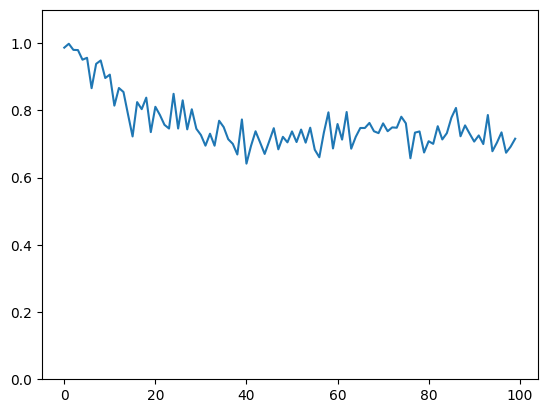

In [79]:
out = exp_eval(outputs1, 20.)
plt.plot(out)
plt.ylim((0., 1.1))
plt.show()

In [89]:
res = np.zeros(num_params)
for i in range(num_params):
    res[i] = exp_eval(outputs[:, i].mean(axis=0), 20.).mean()

logger()

2026-03-07 23:38:54 | 


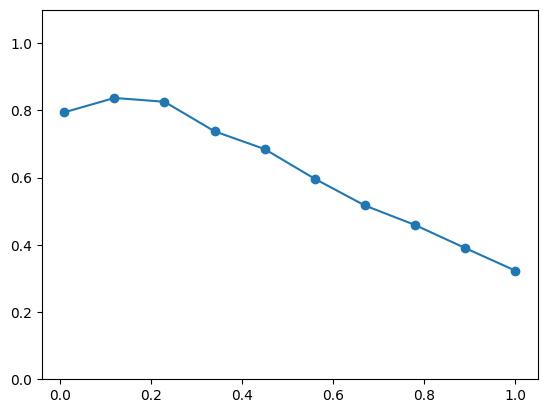

In [90]:
plt.plot(params, res, '-o')
plt.ylim((0., 1.1))
plt.show()

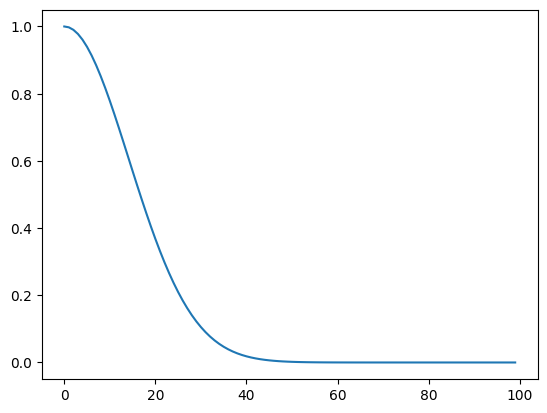

In [58]:
y = np.exp(-np.arange(100)*np.arange(100) / (20**2))
plt.plot(y);